
## <div style="text-align: center;"> Grievance Redressal Survey Results </div>

***<div style="text-align: center;"> S. Naveera Fatima Rizvi </div>***

Source= Synthetic data inspired from the [Grievance Redress Report (GRR-1)](https://www.bisp.gov.pk/SiteImage/Misc/files/GrievanceRedressReport.pdf) by Mott MacDonald Limited

![Questionnaire](Flowchart.png)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
from texttable import Texttable
import plotly.io as pio
pio.renderers.default= 'notebook_connected'
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Load data with a seperate dataframe for seperate sheets

# Load sheet with responses e.g Q1:a, Q2b
df_raw_responses= pd.read_excel("Clean_Grievance_Sample.xlsx", sheet_name='Responses')

#Load sheet with keys to map responses to labels e.g a --> Yes, b ---> No
df_raw_keys= pd.read_excel("Clean_Grievance_Sample.xlsx", sheet_name="Keys")
df_raw_keys= df_raw_keys.set_index("Options")

#Load sheet with question labels mapping to numbers e.g. 
df_raw_questions= pd.read_excel("Clean_Grievance_Sample.xlsx", sheet_name="Questions")


In [3]:
#Responses
df_raw_responses.head()

,PROVINCE,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8
0,AJK/GB,b,a,a,a,a,NaN,NaN,NaN
1,KP,b,a,b,NaN,NaN,b,a,NaN
2,KP,a,a,b,NaN,NaN,b,b,NaN
3,KP,c,b,b,NaN,NaN,b,c,NaN
4,Balochistan,b,a,a,a,a,NaN,NaN,NaN


In [4]:
# Answer Keys
df_raw_keys

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8
Options,,,,,,,,
a,Quality of Service Issues,In Person,Yes,Yes,Yes,Yes,Lack of time,Complaint resolved and I am satisfied
b,Payment Issues,Phone,No,No,No,No,Language barrier,Complaint resolved but I am not satisfied
c,Documentation Issues,Other,NaN,NaN,NaN,NaN,Didn't feel it would make a difference,Complaint not tesolved
d,Eligibility Issues,NaN,NaN,NaN,NaN,NaN,Other,Other
e,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Questions
df_raw_questions

,Number,Question
0,Q1,What was the reason behind your complaint?
1,Q2,How did you lodge a complaint?
2,Q3,Did anyone contact you?
3,Q4,Was your complaint resolved?
4,Q5,Are you satisfied with the resolution?
5,Q6,Did you complain again?
6,Q7,Why didn't you complain again?
7,Q8,What was the outcome of complaining again?


In [6]:
# Create a nested dictionary mapping question numbers to answers 

dict_map = {} # Create empty dictionary for question number: {answer:option label} pairs
for question_number in df_raw_keys.columns:
    dict_answers = {} # For each question, create an empty dictionary for the relevant answer-option: label pairs 
    df_answer_labels = df_raw_keys[question_number].dropna() # Drop missing values (when there is no relevant label for an option)      
    for option in df_answer_labels.index:
        dict_answers[option] = df_answer_labels[option]
        dict_map[question_number] = dict_answers

df = df_raw_responses.replace(dict_map) # Use the newly created dictionary to map relevant answers to question and save the results in a new dataframe

new_colnames = list(df_raw_questions["Number"]+": "+df_raw_questions["Question"])
new_colnames.insert(0,"Province")
df.columns = new_colnames

df.head()

,Province,Q1: What was the reason behind your complaint?,Q2: How did you lodge a complaint?,Q3: Did anyone contact you?,Q4: Was your complaint resolved?,Q5: Are you satisfied with the resolution?,Q6: Did you complain again?,Q7: Why didn't you complain again?,Q8: What was the outcome of complaining again?
0,AJK/GB,Payment Issues,In Person,Yes,Yes,Yes,NaN,NaN,NaN
1,KP,Payment Issues,In Person,No,NaN,NaN,No,Lack of time,NaN
2,KP,Quality of Service Issues,In Person,No,NaN,NaN,No,Language barrier,NaN
3,KP,Documentation Issues,Phone,No,NaN,NaN,No,Didn't feel it would make a difference,NaN
4,Balochistan,Payment Issues,In Person,Yes,Yes,Yes,NaN,NaN,NaN


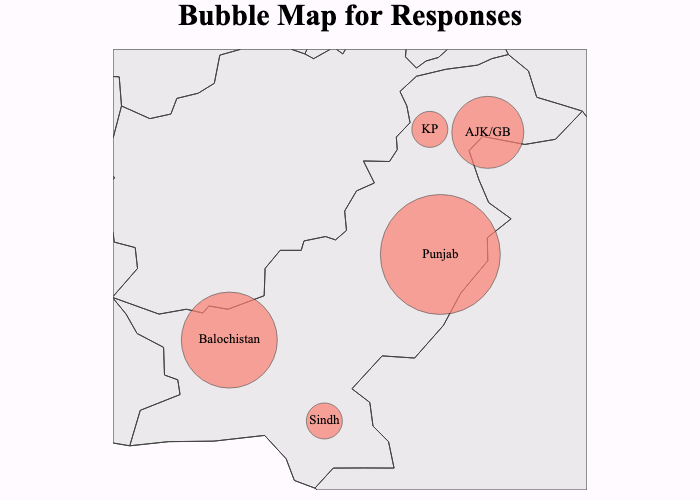

In [7]:
### Plot Bubble Map to show which Province has the most complaints

# Create a dataframe for lat_long data
lat_long= pd.DataFrame({
    'Province':["Punjab","Sindh","KP","Balochistan","AJK/GB"],
    'Lat':[31.1704,25.8943,34.9526,28.4907,34.8641],
    'Long':[72.7097,68.5247,72.3311,65.0958,74.4232]
    }).set_index("Province")

# Join Province Counts with Lat Long data
data_map = df["Province"].value_counts().to_frame()
data_map = data_map.join(lat_long)
data_map = data_map.reset_index()
data_map.rename(columns={'index':'Region'}, inplace=True)

# Plot Bubble map
fig = go.Figure()
fig.add_trace(go.Scattergeo(
                    lat=data_map["Lat"],lon=data_map["Long"],
                    marker = dict(
                    size = data_map["Province"]*12,
                    color='salmon',
                    line_color='rgb(40,40,40)',
                    line_width=0.7),
                    showlegend=False)
            )

fig.add_trace(go.Scattergeo(
                    lat=data_map["Lat"],lon=data_map["Long"],
                    text=data_map["Region"],
                    textposition="middle center",
                    textfont=dict(size =13, color='black', family='serif'),
                    mode='text',
                    showlegend=False)
                )

fig.update_layout(
        title_text='<b>Bubble Map for Responses',
        titlefont=dict(size =30, color='black', family='serif'),
        title_x=0.5,
        geo=dict(scope='asia',lataxis_range=[23.9,37.5], lonaxis_range=[60.9, 78],
        landcolor = 'rgba(217, 217, 217,0.5)',
        showcountries = True,
        showcoastlines=True,
        bgcolor='rgb(255,250,255)'),
        paper_bgcolor='rgb(255,250,255)',
        margin={"r":10,"t":50,"l":10,"b":10}
    )
fig.show("png")


In [8]:

def plot_pie(data,color_list,title,ax_num):
    """
    Generates and plots a pie chart based on the provided dataset.
    Args:
        df (pd.DataFrame): The dataframe containing the data to plot.
        colors (list[str]): A list of hex codes or color names for the pie slices.
        title (str): The title to display above the chart.
        ax (matplotlib.axes.Axes): The specific subplot axis where the chart should be drawn.

    Returns:
        matplotlib.axes.Axes: The axis object containing the plotted pie chart. 
    """
    data.value_counts().plot(
        kind='pie',
        ax=ax[ax_num], 
        colors= color_list,
        autopct='%1.1f%%',
        textprops={'fontsize': 12,'color':'darkblue','fontweight':550,'family':'serif'},
        wedgeprops = {'width':0.6,'linewidth':3, 'edgecolor':(1,1,1,1)})

    ax[ax_num].set_title(title, 
        loc='center', fontsize=25, fontweight="bold",family='serif')
    ax[ax_num].set_ylabel("")
    ax[ax_num].tick_params(axis='x', labelsize=25)
    ax[ax_num].tick_params(axis='y', labelsize=25)


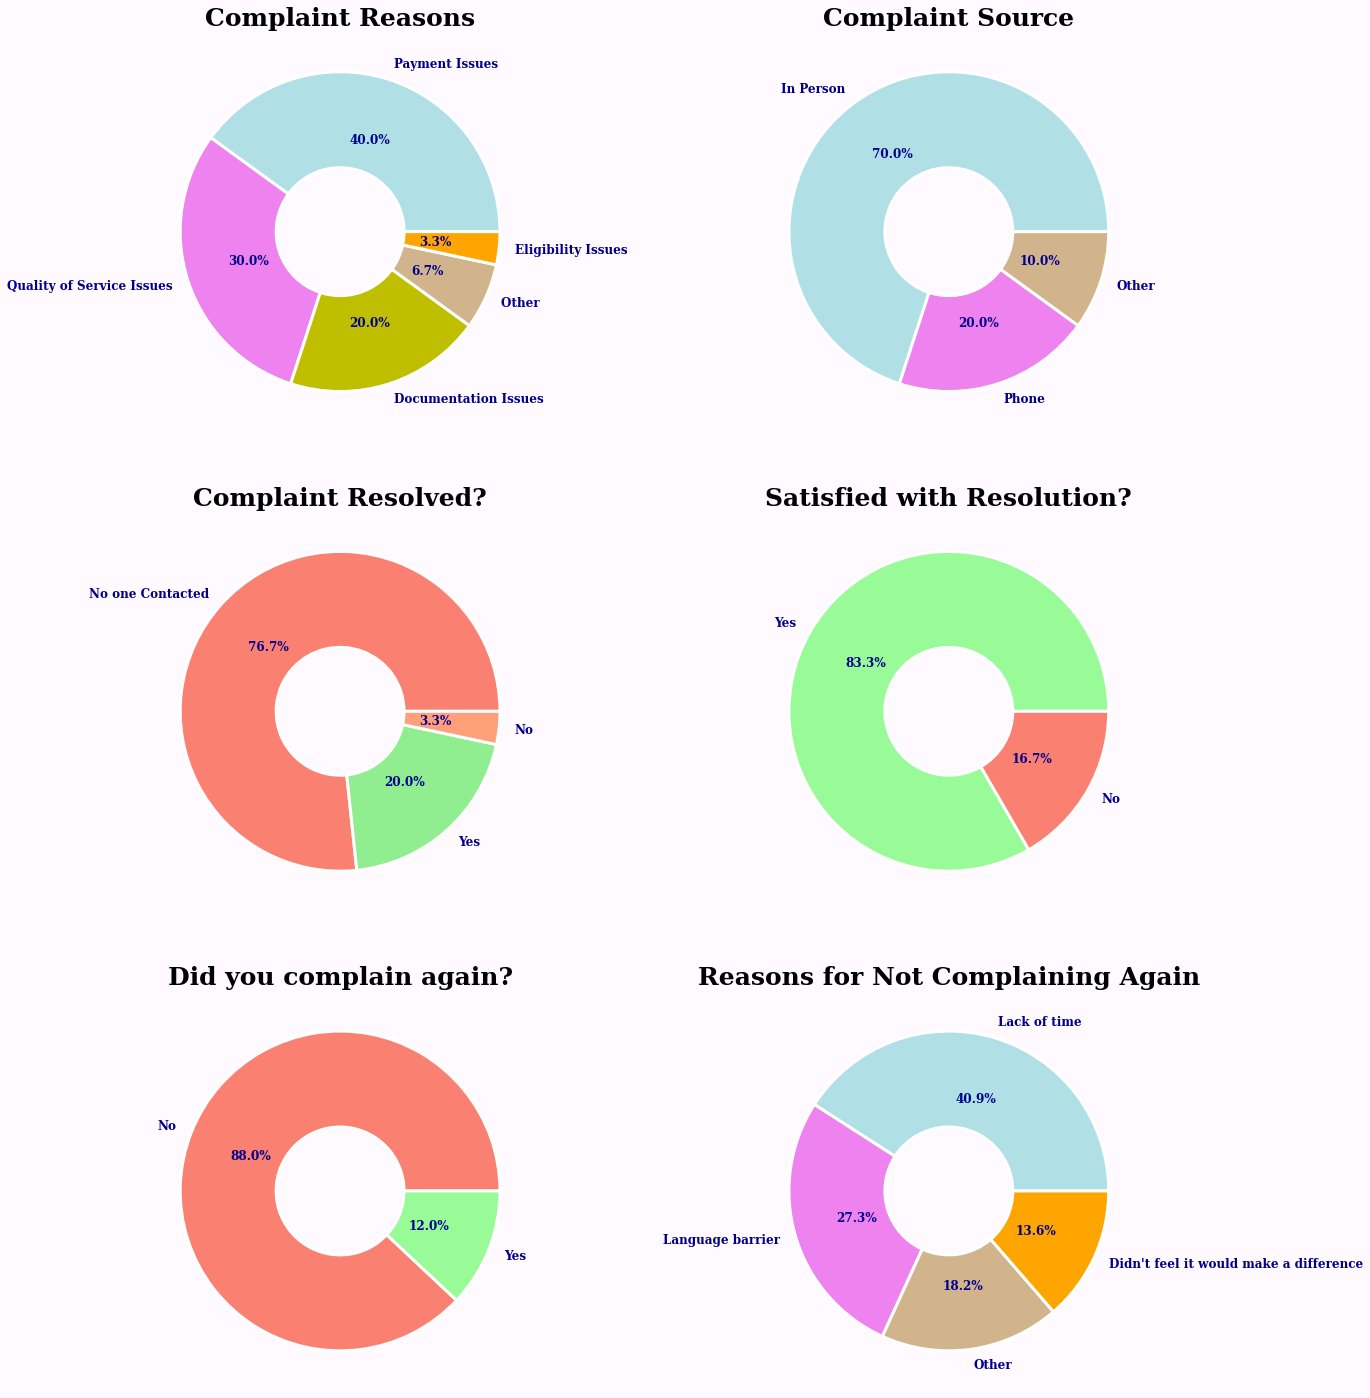

In [9]:
# Plot piecharts for Questions 1,2,4,5,6 and 7 using the function defined above
fig,ax= plt.subplots(3,2,figsize=(20,25))

ax = ax.flatten()

plot_pie(df["Q1: What was the reason behind your complaint?"],['powderblue', 'violet','y','tan','orange'],'Complaint Reasons',0)
plot_pie(df["Q2: How did you lodge a complaint?"],['powderblue','violet','tan'],'Complaint Source',1)
plot_pie(df["Q4: Was your complaint resolved?"].fillna("No one Contacted"),['salmon', 'lightgreen','lightsalmon'],'Complaint Resolved?',2)
plot_pie(df["Q5: Are you satisfied with the resolution?"].dropna(),['palegreen','salmon'],'Satisfied with Resolution?',3)
plot_pie(df["Q6: Did you complain again?"].dropna(),['salmon', 'palegreen'],'Did you complain again?',4)
plot_pie(df["Q7: Why didn't you complain again?"].dropna(),['powderblue', 'violet','tan','orange'],'Reasons for Not Complaining Again',5)


fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))
plt.show()



In [10]:
# Define function for plotting barchars
def plot_bars(col,barcolors):
    """
    Generates a bar chart for a specified data column.
    Args:
        column (pd.Series): The data column to be visualized.
        colors (list[str]): A list of color hex codes or names for the bars.

    Returns:
        matplotlib.axes.Axes: The axes object containing the bar chart.
    """
    data_bar= pd.crosstab(df[col],df["Province"],dropna=False)
    data_bar["Total"] = data_bar.sum(axis=1)

    #Convert numbers to percentages
    data_bar= data_bar.apply(lambda r: r*100/r.sum(),axis=0)
    data_bar= data_bar.round(decimals=1)

    #Reorder columns
    data_bar= data_bar.loc[:,["Punjab","Sindh","KP","Balochistan","AJK/GB","Total"]]
    
    #Plot barchart
    fig,ax= plt.subplots(figsize=(48,20))
    data_bar.T.plot.bar(
        ax=ax, rot=0, legend=False, 
        width=0.8,color=barcolors, edgecolor='k')

    # Add this loop to add the annotations
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        if height>0:
            x, y = p.get_xy() 
            ax.annotate(
                height, (x + width/2, height+1.02),ha='center',
                fontsize=25,fontweight="bold", color='darkblue')

    ax.legend(loc='best',prop={'size': 30})
    ax.set_title("\n"+data_bar.index.name+"\n", loc='center', fontsize=50, fontweight="bold", family='serif')
    ax.set_xlabel('Region',fontsize=40, fontweight="bold",family='serif')
    ax.set_ylabel('Percentage',fontsize=40, fontweight="bold",family='serif')
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
    
    fig.set_facecolor(tuple(np.array([255, 250, 255]) / 255))
    fig.tight_layout()

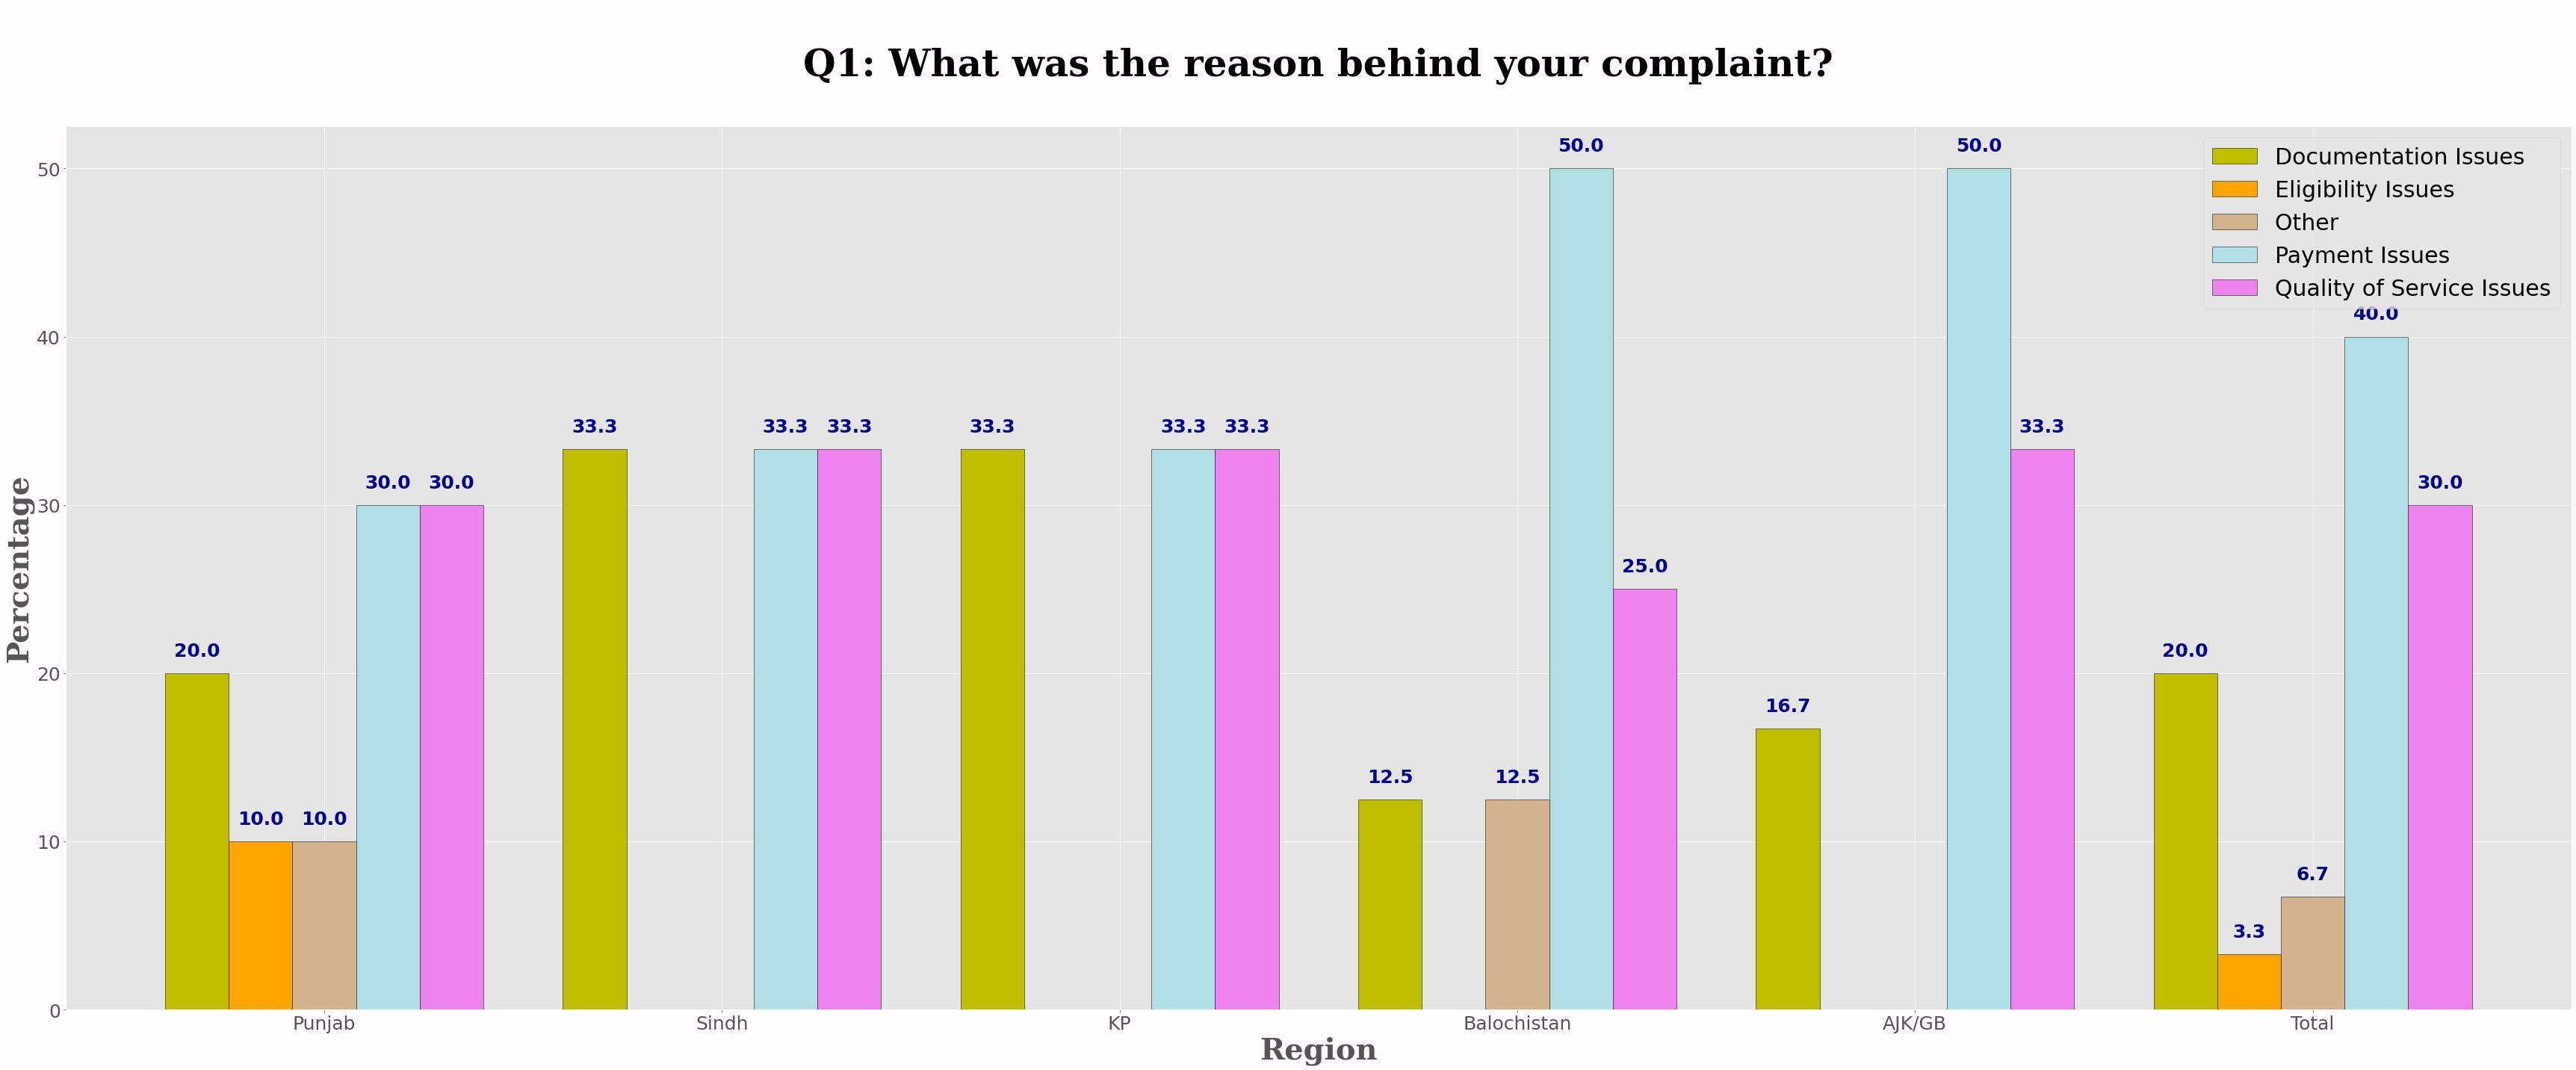

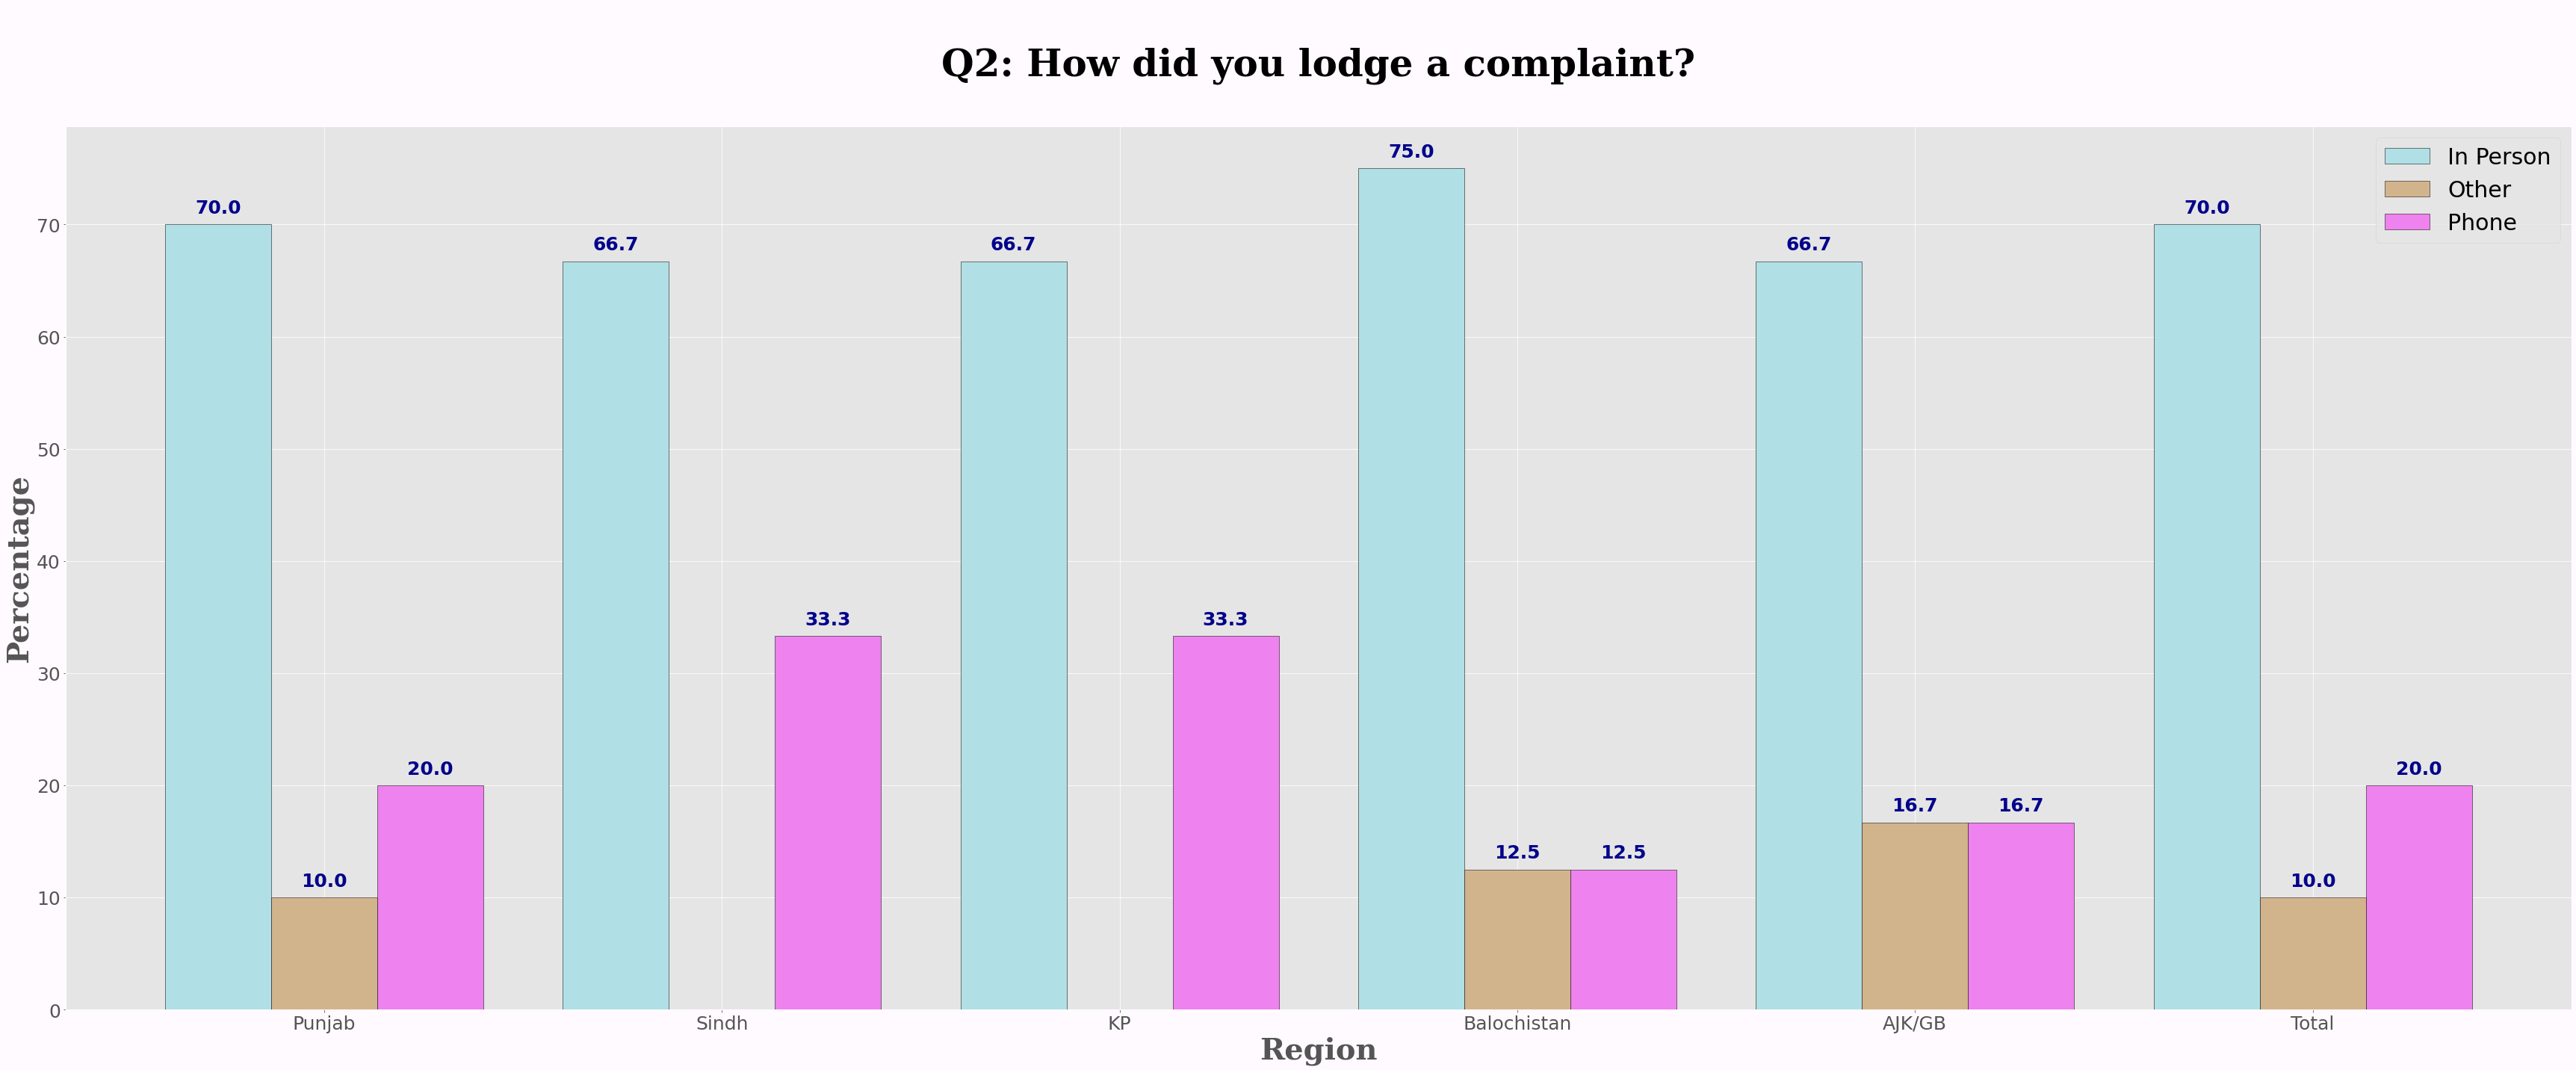

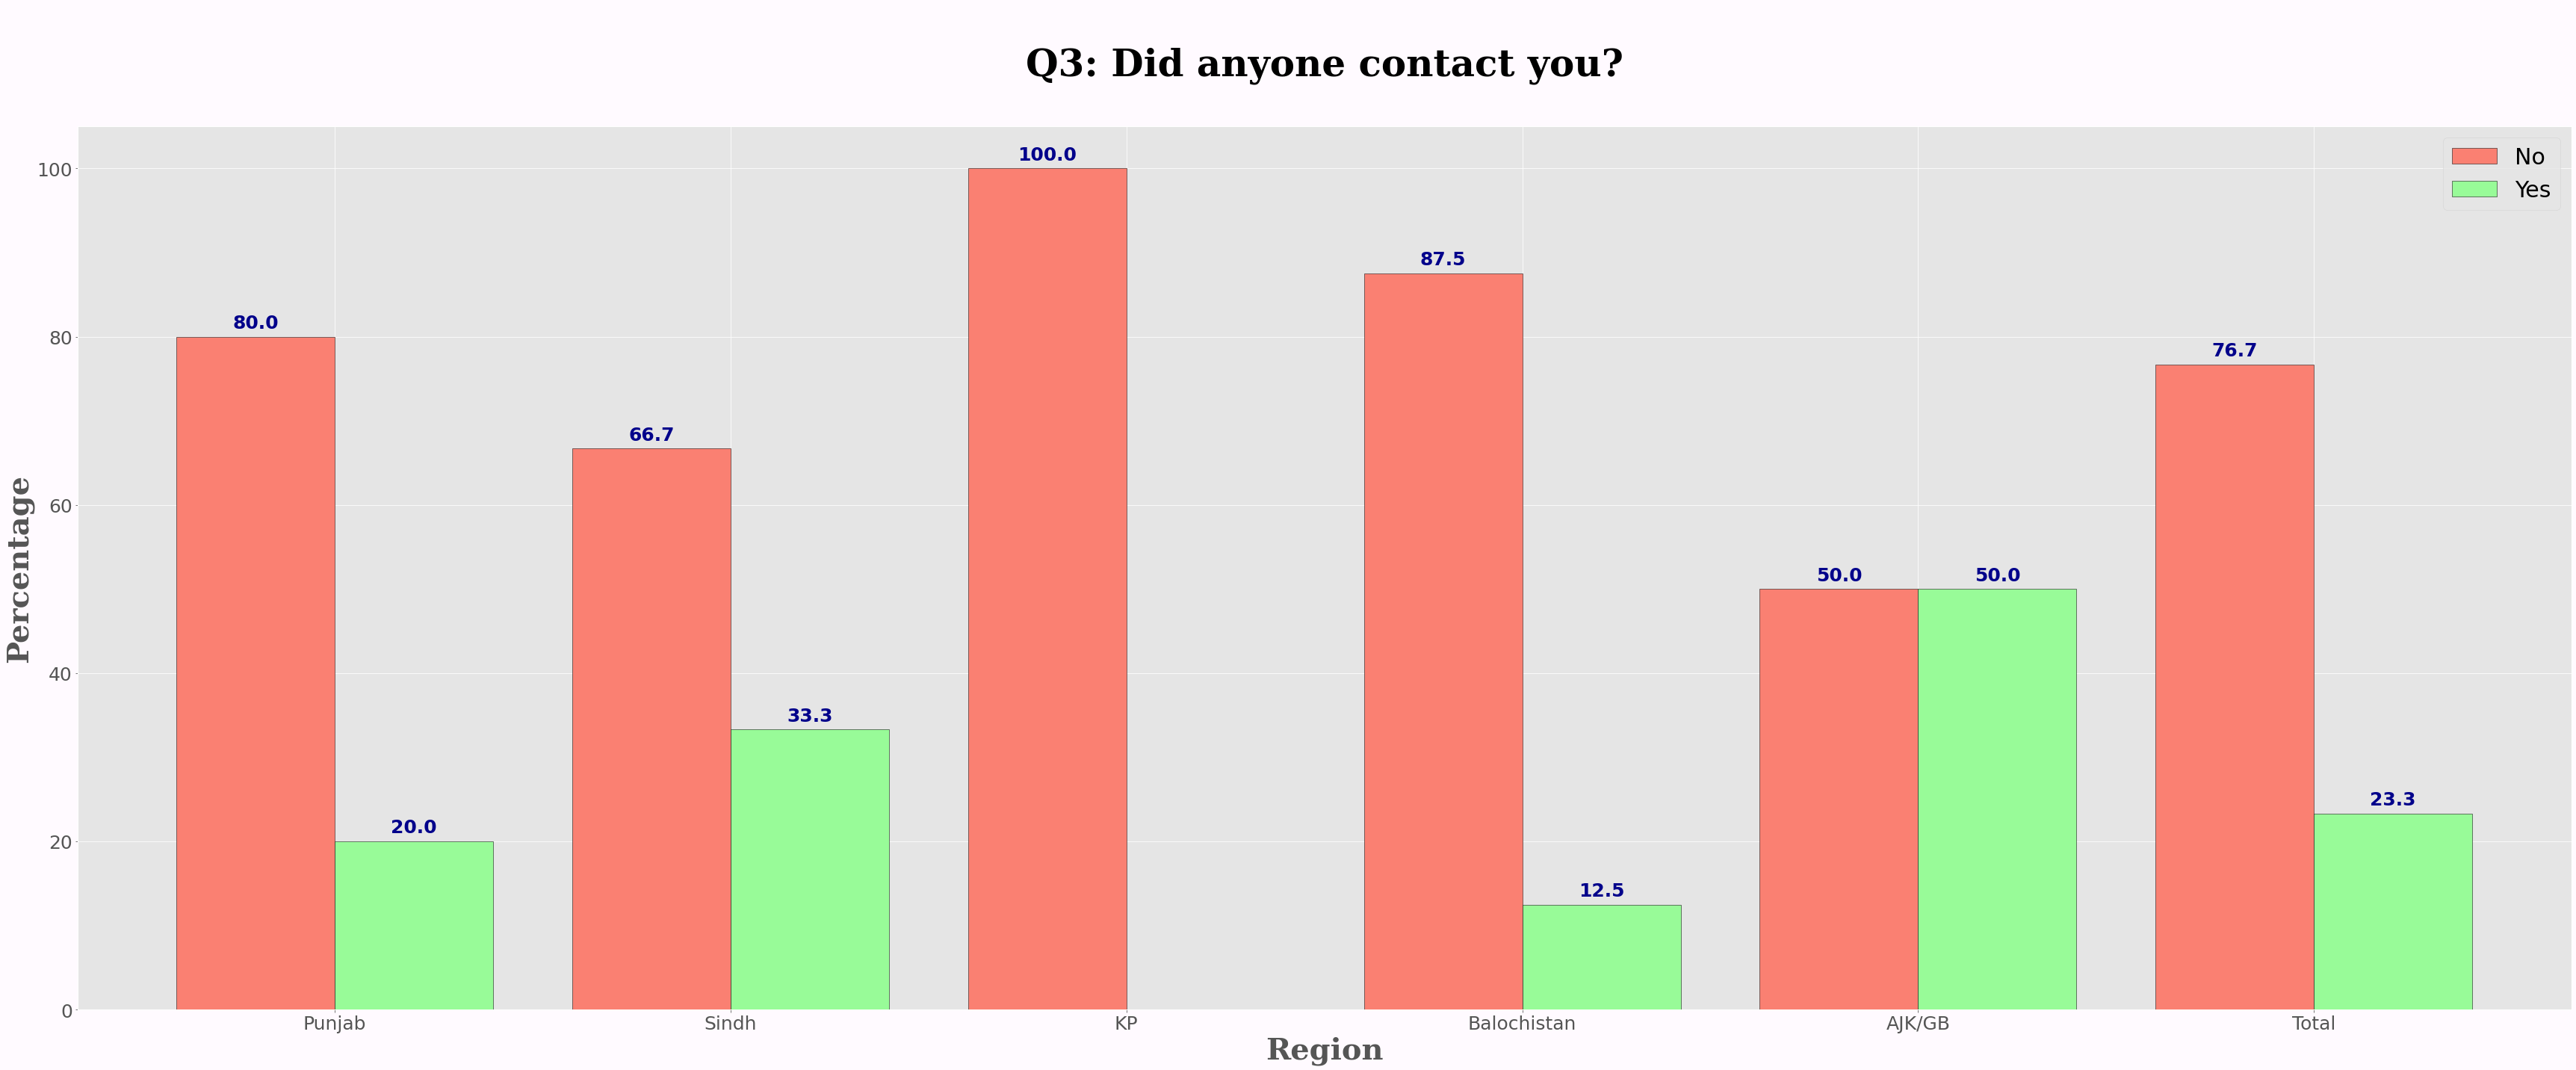

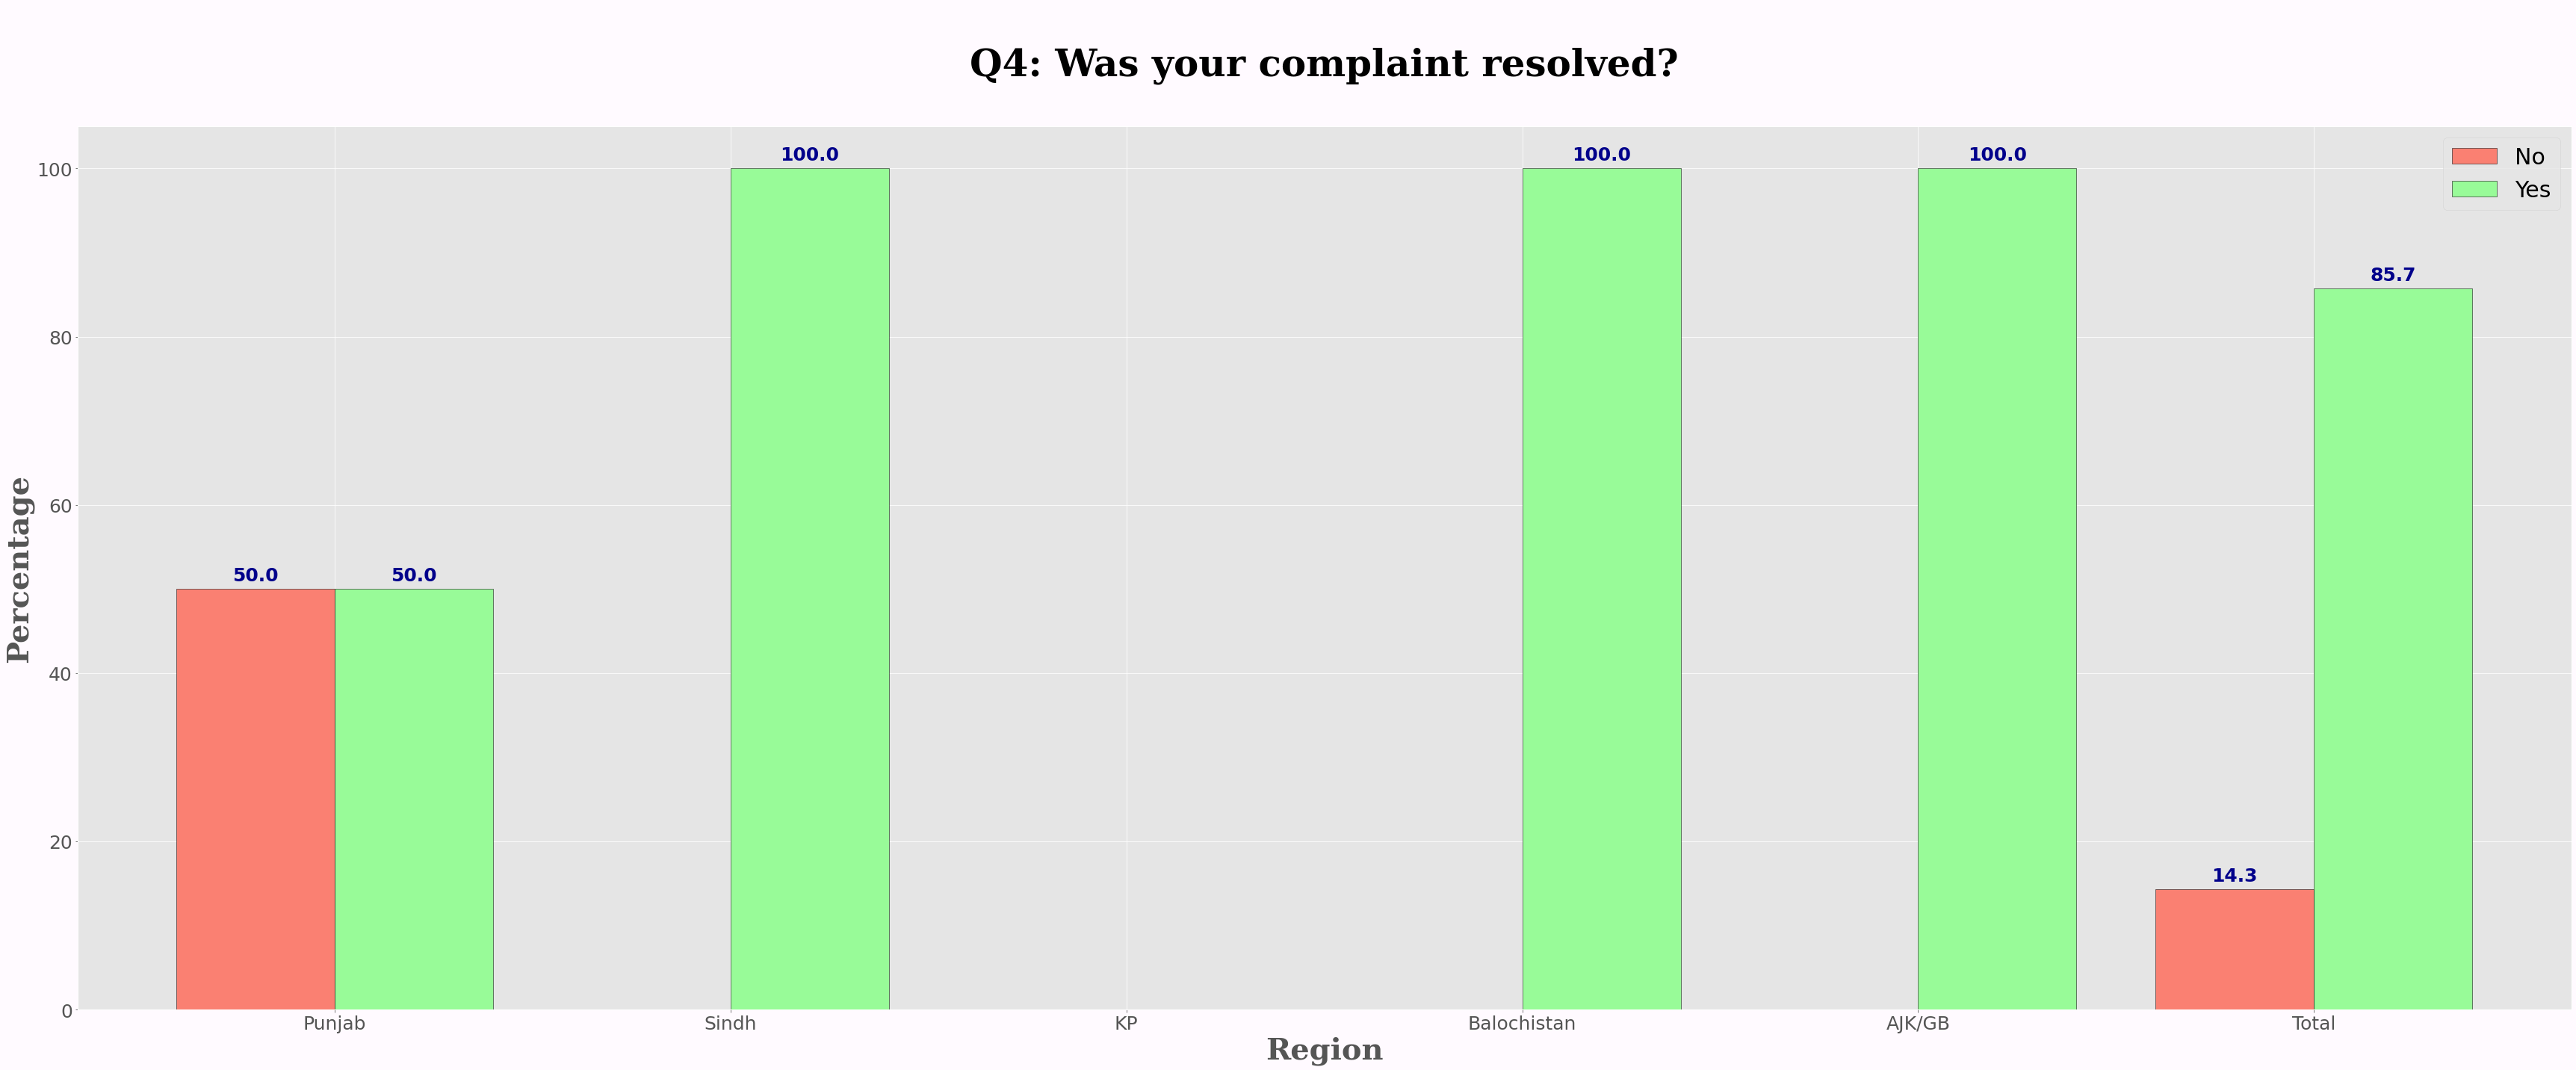

In [11]:
# Plot Bar charts

plot_bars(df.columns[1],['y','orange','tan','powderblue','violet'])
plot_bars(df.columns[2],['powderblue','tan','violet'])
plot_bars(df.columns[3],{'Yes':'palegreen','No':'salmon'})
plot_bars(df.columns[4],{'Yes':'palegreen','No':'salmon'})

In [12]:
! jupyter nbconvert --to webpdf Grievance_redressal_sampledata.ipynb

[NbConvertApp] Converting notebook Grievance_redressal_sampledata.ipynb to webpdf
[NbConvertApp] Writing 901426 bytes to Grievance_redressal_sampledata.pdf
